# Практическое занятие №7: Машинное обучение с scikit-learn I.

Подготовка данных для ML, разделение на выборки, первая модель (линейная
регрессия или k-NN)

## Задание

### Вариант 10: Квартиры в Сан-Франциско (задача регрессии) — Игрушечный датасет

- Датасет: fetch_california_housing()
- Цель: сравнить линейную регрессию и KNeighborsRegressor с разным k.
- Особенность: построить график зависимости метрики MSE от параметра k (от 1 до 30) для обоих алгоритмов и выбрать лучший.

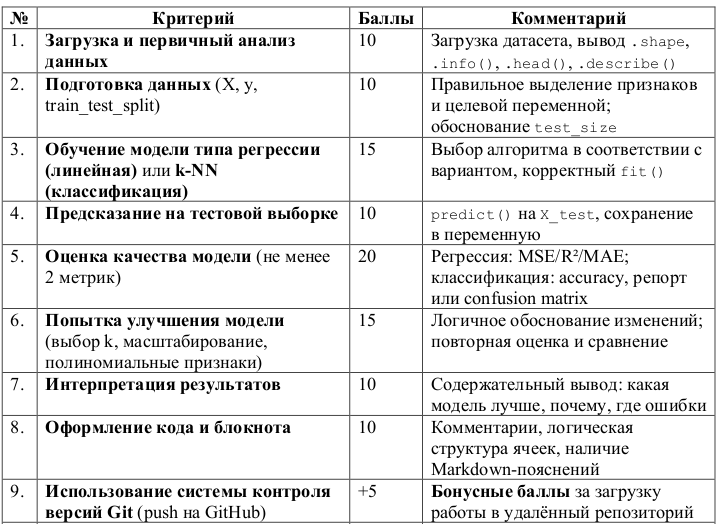

### Импорт библиотек

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # для работы с метриками качества для лин регрессии

from sklearn.neighbors import KNeighborsRegressor # для работы с алгоритмом k-ближайших соседей (k-NN)
from sklearn.preprocessing import StandardScaler 

### Подготовка данных для машинного обучения:

In [34]:
# Загрузка датасета
housing = fetch_california_housing()

# Матрица признаков (на основе этого строятся предсказания)
X = housing.data

# Целевая переменная (то что предсказываем)
y = housing.target

print("Размерность X:")
print(X.shape)

print("\nРазмерность y:")
print(y.shape)

# DataFrame нужен для удобного первичного анализа
df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y

print("Размерность датасета:")
print(df.shape)

print("\nПервые 5 строк:")
print(df.head())

print("\nИнформация о датасете:")
df.info()

print("\nОбщая статистика:")
print(df.describe())

print("\nКоличество пропусков:")
print(df.isnull().sum())

Размерность X:
(20640, 8)

Размерность y:
(20640,)
Размерность датасета:
(20640, 9)

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms 

Данные проверены для работы. Пропусков не обнаружено.

### Разделение на обучающую и тестовую выборки

In [36]:
X_train, X_test, y_train, y_test = train_test_split( # train - обучение, test - проверка
X, y,
test_size=0.2,   # 20% данных — в тестовую выборку
random_state=42, # фиксируем для воспроизводимости
stratify=None    # для классификации — сохраняет пропорции классов
)

Датасет был разделён на обучающую и тестовую выборки в соотношении 80/20. Это классическое соотношение в ML.

Обучающая выборка используется
для обучения модели,
а тестовая — для проверки качества
предсказаний на новых данных.

### Линейная регрессия

In [37]:
# Создаём и обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)
# Коэффициенты модели
print("Коэффициенты:", model.coef_)
print("Свободный член:", model.intercept_)


Коэффициенты: [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Свободный член: -37.02327770606391


Теперь создана и обучена модель линейной регрессии на обучающей выборке.

После обучения модель вычислила коэффициенты признаков, которые показывают влияние характеристик районов на стоимость жилья.

### Предсказание на тестовой выборке

После обучения модель используется для предсказания стоимости жилья на тестовых данных.

Далее выполняется сравнение реальных и предсказанных значений.

In [38]:
# Предсказание на тестовых данных
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Real Price': y_test[:10],
    'Predicted Price': y_pred[:10]
})

print(comparison)

   Real Price  Predicted Price
0     0.47700         0.719123
1     0.45800         1.764017
2     5.00001         2.709659
3     2.18600         2.838926
4     2.78000         2.604657
5     1.58700         2.011754
6     1.98200         2.645500
7     1.57500         2.168755
8     3.40000         2.740746
9     4.46600         3.915615


Модель линейной регрессии выполнила предсказание
стоимости жилья на тестовой выборке.

Предсказанные значения в большинстве случаев
близки к реальным,
однако для некоторых объектов
наблюдаются заметные отклонения,
что говорит о наличии ошибок предсказания.

### Оценка качества модели линейной регрессией

In [46]:
# считаем метрики

lr_mse = mean_squared_error(y_test, y_pred) # Средний квадрат ошибки
mae = mean_absolute_error(y_test, y_pred) # Средняя абсолютная ошибка
r2 = r2_score(y_test, y_pred) # Доля дисперсии, объяснённая моделью

# вывод результатов

print("Метрики качества линейной регрессии:")

print(f"\nMSE: {lr_mse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R²: {r2:.3f}")

Метрики качества линейной регрессии:

MSE: 0.556
MAE: 0.533
R²: 0.576


Модель линейной регрессии показала среднее качество предсказаний.

Средняя ошибка модели составляет около 0.53, а значение R² = 0.576 показывает,
что модель объясняет примерно 58% зависимости между признаками и стоимостью жилья.

Модель работает, но предсказывает не идеально.

### KNeighborsRegressor

Перед обучением модели KNeighborsRegressor признаки были масштабированы
с помощью StandardScaler, так как алгоритм k-NN чувствителен к масштабу данных.

In [47]:
# Создание scaler
scaler = StandardScaler()

# Стандартизация признаков
X_train_scaled = scaler.fit_transform(X_train)

# Преобразование test
X_test_scaled = scaler.transform(X_test)

# Создание модели, 5 соседей
knn = KNeighborsRegressor(n_neighbors=5)

# Обучение
knn.fit(X_train_scaled, y_train)

# Предсказание
y_pred_knn = knn.predict(X_test_scaled)

# метрики
mse_knn = mean_squared_error(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("Метрики качества KNN:")

print(f"\nMSE: {mse_knn:.3f}")
print(f"MAE: {mae_knn:.3f}")
print(f"R²: {r2_knn:.3f}")

Метрики качества KNN:

MSE: 0.432
MAE: 0.446
R²: 0.670


Модель KNeighborsRegressor показала более высокое качество, чем линейная регрессия.

Значения MSE и MAE стали меньше, а коэффициент R² увеличился до 0.670,
что говорит о более точном предсказании стоимости жилья.

Это означает, что KNN лучше улавливает зависимости между признаками и ценой жилья для данного датасета.

### Подбор оптимального значения k

Для улучшения качества модели
был выполнен подбор параметра k
для KNeighborsRegressor.

Для каждого значения k от 1 до 30
вычислялась метрика MSE.

In [48]:
k_values = range(1, 31)

mse_scores = []

for k in k_values:

    # Создание модели
    knn_tmp = KNeighborsRegressor(
        n_neighbors=k
    )

    # Обучение
    knn_tmp.fit(X_train_scaled, y_train)

    # Предсказание
    y_pred_tmp = knn_tmp.predict(X_test_scaled)

    # MSE
    knn_mse = mean_squared_error(
        y_test,
        y_pred_tmp
    )

    # Сохранение
    mse_scores.append(knn_mse)

Построение графика зависимости k от MSE:

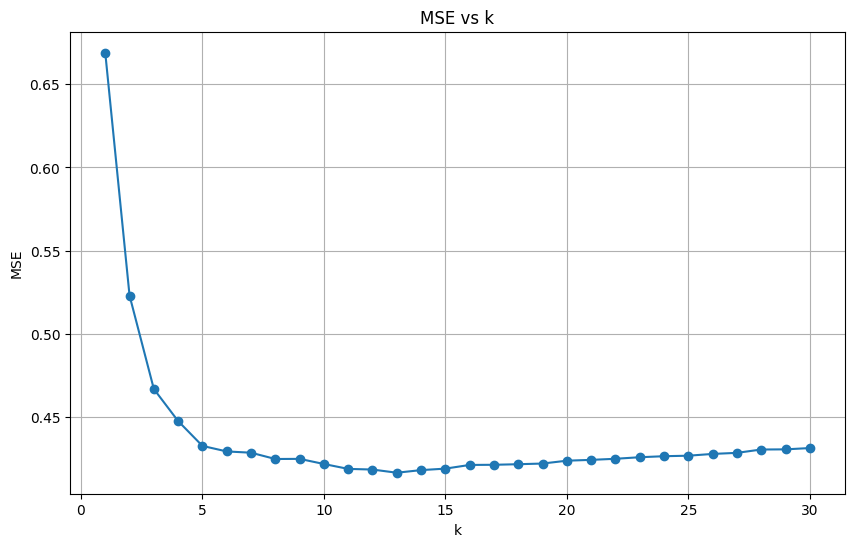

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_values,
    mse_scores,
    marker='o'
)

plt.title('MSE vs k')
plt.xlabel('k')
plt.ylabel('MSE')

plt.grid(True)

plt.show()

Лучший k выбирается таким образом, где MSE минимальна. Найдем это значение:

In [50]:
best_k = k_values[
    mse_scores.index(min(mse_scores))
]

best_mse = min(mse_scores)

print(f"Лучшее значение k: {best_k}")
print(f"Минимальное MSE: {best_mse:.3f}")

Лучшее значение k: 13
Минимальное MSE: 0.416


Сравнение значений MSE для KNN и Линейной регрессии

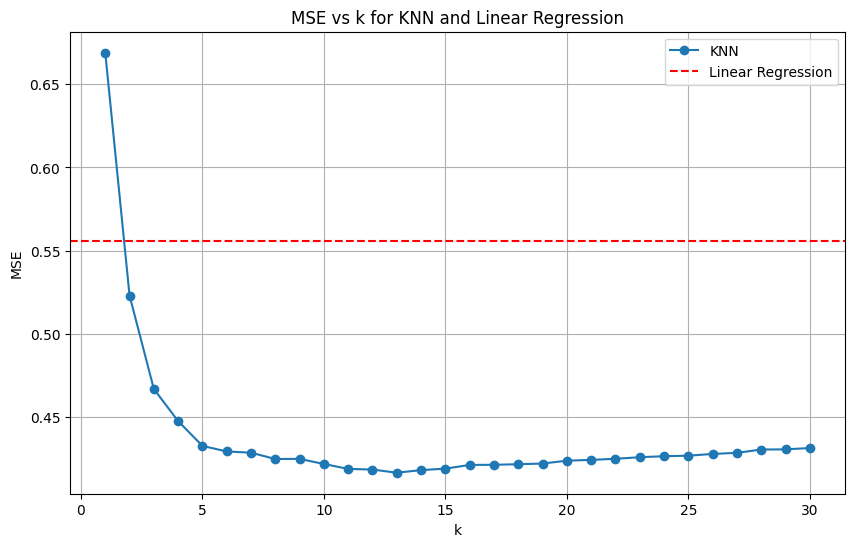

In [55]:
plt.figure(figsize=(10, 6))

# KNN
plt.plot(
    k_values,
    mse_scores,
    marker='o',
    label='KNN'
)

# Лин регрессия
plt.axhline(
    y=lr_mse,
    color='red',
    linestyle='--',
    label='Linear Regression'
)

plt.xlabel('k')
plt.ylabel('MSE')

plt.title('MSE vs k for KNN and Linear Regression')

plt.legend()

plt.grid(True)

plt.show()

### Вывод

В ходе работы были обучены и сравнены модели Linear Regression и KNeighborsRegressor
для прогнозирования стоимости жилья.

Линейная регрессия показала среднее качество предсказания, однако модель KNN после масштабирования признаков и подбора параметра k показала более низкое значение MSE
и более высокий коэффициент R².

Лучший результат был получен примерно при k = 13.

Это показывает, что для данного датасета зависимость между признаками и стоимостью жилья
является не полностью линейной, поэтому KNN лучше улавливает локальные закономерности данных.

Таким образом, для данного датасета KNN оказался эффективнее, чем Linear Regression.